In [45]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [46]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True
)

env = env.unwrapped

n_states = env.observation_space.n
n_actions = env.action_space.n

In [47]:
num_episodes = 10000
gamma = 0.93
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9996

max_steps_per_episode = 200

In [48]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------
Q = np.zeros((n_states, n_actions))
episode_rewards = []

In [49]:
def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        # Exploration
        return env.action_space.sample()
    else:
        # Exploitation
        return np.argmax(Q[state])

In [50]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------
epsilon = epsilon_start

for episode in range(num_episodes):

    state, info = env.reset()
    total_reward = 0

    for step in range(max_steps_per_episode):

        action = choose_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])
        Q[state, action] = Q[state, action] + alpha * (
            target - Q[state, action]
        )
        state = next_state

        total_reward += reward
        if terminated or truncated:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

In [51]:
# -------------------------------------------------
# Calculate State-Value Function
# -------------------------------------------------

state_values = np.max(Q, axis=1)

In [52]:
# -------------------------------------------------
# Extract Learned Policy
# -------------------------------------------------

learned_policy = np.argmax(Q, axis=1)

In [53]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)

In [54]:
# -------------------------------------------------
# Output
# -------------------------------------------------
print("Name: Puli Naga Neeraj\n")
print("Reg No: 212223240130")
print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)

Name: Puli Naga Neeraj

Reg No: 212223240130

Final Q-table:
[[0.095 0.092 0.104 0.092]
 [0.069 0.088 0.051 0.094]
 [0.095 0.088 0.092 0.082]
 [0.064 0.04  0.036 0.079]
 [0.131 0.085 0.103 0.071]
 [0.    0.    0.    0.   ]
 [0.092 0.038 0.087 0.037]
 [0.    0.    0.    0.   ]
 [0.123 0.119 0.149 0.179]
 [0.248 0.274 0.173 0.218]
 [0.289 0.28  0.191 0.141]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.203 0.298 0.396 0.28 ]
 [0.489 0.679 0.547 0.489]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.104 0.094 0.095 0.079]
 [0.131 0.    0.092 0.   ]
 [0.179 0.274 0.289 0.   ]
 [0.    0.396 0.679 0.   ]]

Learned Policy:
[['R' 'U' 'L' 'U']
 ['L' 'L' 'L' 'L']
 ['U' 'D' 'L' 'L']
 ['L' 'R' 'D' 'L']]

Average reward over last 1000 episodes: 0.486


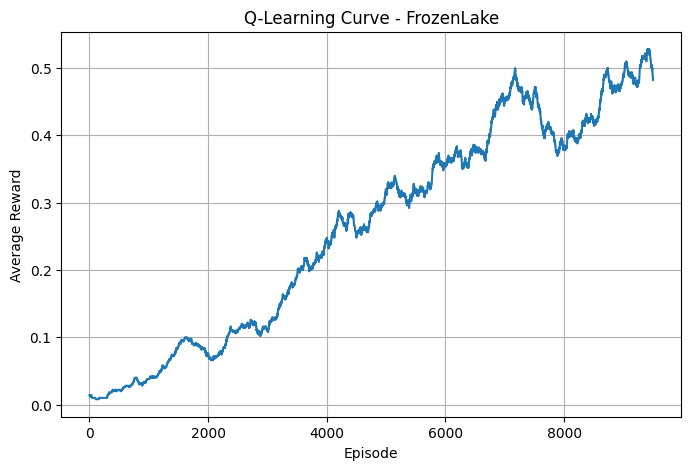

In [55]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()